# Weather forecasts on ERA5 with hybrid sigma-pressure levels

This notebook is the hybrid-level counterpart of
[weather_forecast_on_era5.ipynb](weather_forecast_on_era5.ipynb): it initializes
the Dinosaur dynamical core from ERA5 and runs a two-day forecast at T170 with
32 layers, but on *hybrid sigma-pressure levels* instead of sigma levels.

Hybrid levels put the interface between layers `k` and `k+1` at the pressure
`p = A + B * surface_pressure`. Near the ground `B → 1` and the levels follow the
terrain like sigma levels; aloft `A` dominates and the levels flatten out into
surfaces of constant pressure, which avoids the spurious pressure-gradient
errors that sloping sigma surfaces produce over steep orography. This is the
vertical coordinate of ECMWF's IFS (ERA5 itself is on 137 hybrid levels), and
`PrimitiveEquationsHybrid` solves the primitive equations on it with the
energy-conserving vertical discretization of Simmons & Burridge (1981).

We use ECMWF's 137-level coefficients interpolated to 32 layers, run the same
forecast on 32 equidistant sigma levels for comparison, and verify both against
ERA5 at +24 h and +48 h.

One practical note: ECMWF's levels extend to 0 hPa, with a 0.02 hPa top layer
in the mesosphere, where the IFS relies on a sponge layer. Dinosaur has no upper
sponge, and a 32-layer interpolation of the full set becomes unstable at T170
within an hour (the top layers blow up, independent of the time step), so we
drop the interfaces above 10 hPa before interpolating (`p_top=10.0`). This
puts the model top where the equidistant sigma configuration effectively has
it (its top layer spans 0-31 hPa) and is stable.

## Setup code

### Installation

In [1]:
# ! pip install -U -q dinosaur gcsfs
import sys; sys.path.insert(0, "/root/src")

### Imports

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray

from dinosaur import coordinate_systems
from dinosaur import filtering
from dinosaur import hybrid_coordinates
from dinosaur import primitive_equations
from dinosaur import scales
from dinosaur import sigma_coordinates
from dinosaur import spherical_harmonic
from dinosaur import time_integration
from dinosaur import vertical_interpolation

units = scales.units

### Utilities

In [3]:
def attach_data_array_units(array):
  attrs = dict(array.attrs)
  units = attrs.pop('units', None)
  if units in {'(0 - 1)', '%', '~'}:
    units = None
  if units is not None:
    data = scales.units.parse_expression(units) * array.data
  else:
    data = scales.units.dimensionless * array.data
  return xarray.DataArray(data, array.coords, array.dims, attrs=attrs)


def attach_xarray_units(ds):
  return ds.map(attach_data_array_units)


def xarray_nondimensionalize(ds):
  return xarray.apply_ufunc(scales.DEFAULT_SCALE.nondimensionalize, ds)


def xarray_to_gcm_dict(ds, var_names=None):
  if var_names is None:
    var_names = ds.keys()
  result = {}
  for var_name in var_names:
    data = ds[var_name].transpose(..., 'longitude', 'latitude').data
    if data.ndim == 2:  # missing level dimension
      data = data[np.newaxis, ...]
    result[var_name] = data
  return result


def slice_levels(output, level_indices):
  def get_horizontal(x):
    if x.shape[0] == 1:
      return x
    else:
      return x[level_indices, ...]
  return jax.tree.map(get_horizontal, output)

### Configuration

In [4]:
# simulation grid
layers = 32
ref_temp_si = 250 * units.degK
horizontal = spherical_harmonic.Grid.T170()

# ECMWF's 137 levels below a 10 hPa model top, interpolated to 32 layers (see below)
hybrid_levels = hybrid_coordinates.HybridCoordinates.ecmwf137_interpolated(layers, p_top=10.0)
sigma_levels = sigma_coordinates.SigmaCoordinates.equidistant(layers)

# timescales
dt_si = 5 * units.minute
save_every = 3 * units.hour
total_time = 2 * units.day + save_every
dfi_timescale = 6 * units.hour

# verification
verification_hours = [24, 48]
pressure_levels_hpa = [500.0, 850.0]

physics_specs = primitive_equations.PrimitiveEquationsSpecs.from_si()

## The hybrid level structure

The `A` coefficients (in hPa) vanish at the surface and the `B` coefficients
vanish at the model top, so the lowest layers are terrain following and the
upper layers are isobaric. The plot on the right shows the layer interfaces
for three surface pressures: over high terrain (600 hPa) the sigma levels are
compressed into the lower half of the atmosphere while the hybrid levels
above ~250 hPa stay put.

`minimum_surface_pressure` is the lowest surface pressure at which all layers
keep a positive thickness; ECMWF's coefficients stay valid down to ~300 hPa,
far below the ~500 hPa of the highest Himalayan terrain. (The dynamical core
divides by the layer thickness, so level sets whose `B` decays too quickly
with height, e.g. the defaults of `HybridCoordinates.analytic_levels`, must
not be used over terrain where they invert.)

minimum valid surface pressure: 303 hPa


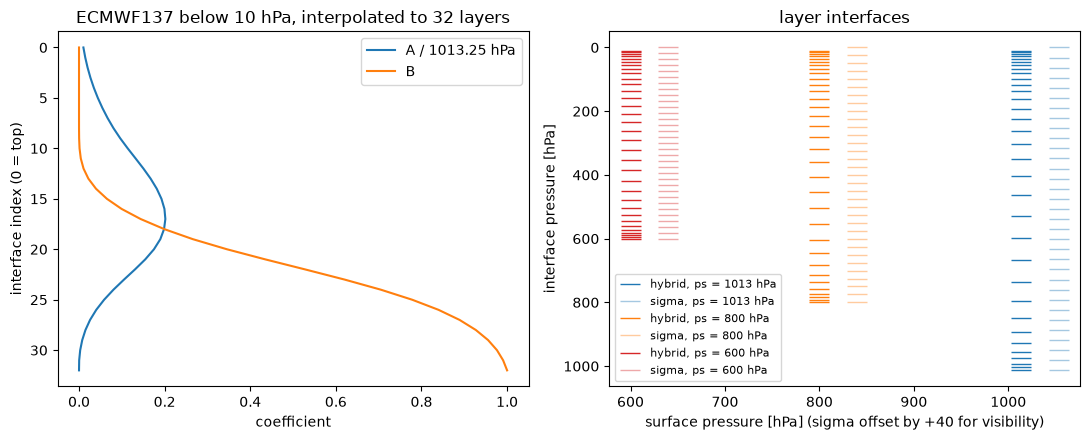

In [5]:
print(f'minimum valid surface pressure: {hybrid_levels.minimum_surface_pressure:.0f} hPa')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.plot(hybrid_levels.a_boundaries / 1013.25, np.arange(layers + 1), label='A / 1013.25 hPa')
ax.plot(hybrid_levels.b_boundaries, np.arange(layers + 1), label='B')
ax.set(xlabel='coefficient', ylabel='interface index (0 = top)', title='ECMWF137 below 10 hPa, interpolated to 32 layers')
ax.invert_yaxis()
ax.legend()
ax = axes[1]
for ps, color in [(1013.25, 'C0'), (800.0, 'C1'), (600.0, 'C3')]:
  p_hybrid = hybrid_levels.pressure_boundaries(ps)
  p_sigma = sigma_levels.boundaries * ps
  ax.plot(np.full(layers + 1, ps), p_hybrid, '_', color=color, markersize=14, label=f'hybrid, ps = {ps:.0f} hPa')
  ax.plot(np.full(layers + 1, ps + 40), p_sigma, '_', color=color, markersize=14, alpha=0.4, label=f'sigma, ps = {ps:.0f} hPa')
ax.set(xlabel='surface pressure [hPa] (sigma offset by +40 for visibility)', ylabel='interface pressure [hPa]', title='layer interfaces')
ax.invert_yaxis()
ax.legend(fontsize=8)
plt.tight_layout()

## Load source data

We load ERA5 on its native 137 model levels at the initial time, plus the
pressure-level analyses at the verification times.

In [6]:
ERA5_PL = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
ERA5_ML = 'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1'
init_time = np.datetime64('1990-05-01T00')


def open_era5(path, time):
  ds = xarray.open_zarr(path, chunks=None, storage_options=dict(token='anon'))
  return ds.sel(time=time)


desired_lon = 180/np.pi * horizontal.nodal_axes[0]
desired_lat = 180/np.pi * np.arcsin(horizontal.nodal_axes[1])

ds_arco_era5 = xarray.merge([
    open_era5(ERA5_PL, init_time).drop_dims('level'),
    open_era5(ERA5_ML, init_time),
])
ds = ds_arco_era5[[
    'u_component_of_wind',
    'v_component_of_wind',
    'temperature',
    'specific_humidity',
    'specific_cloud_liquid_water_content',
    'specific_cloud_ice_water_content',
    'surface_pressure',
]]
raw_orography = ds_arco_era5.geopotential_at_surface

ds_init = attach_xarray_units(ds.compute().interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] = attach_data_array_units(raw_orography.interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] /= scales.GRAVITY_ACCELERATION

source_vertical = hybrid_coordinates.HybridCoordinates.ECMWF137()

verification = {}
for hours in verification_hours:
  ds_verif = open_era5(ERA5_PL, init_time + np.timedelta64(hours, 'h'))
  ds_verif = xarray.merge([
      ds_verif[['temperature', 'u_component_of_wind', 'v_component_of_wind', 'geopotential']].sel(level=pressure_levels_hpa),
      ds_verif[['surface_pressure']],
  ])
  verification[hours] = ds_verif.compute().interp(latitude=desired_lat, longitude=desired_lon)

## Build initial conditions

The model-level inputs are conservatively regridded from ERA5's 137 hybrid
levels to the model's levels: `regrid_hybrid_to_hybrid` for the hybrid model
and `regrid_hybrid_to_sigma` for the sigma model.

In [7]:
ds_nondim_init = xarray_nondimensionalize(ds_init)
model_level_inputs = xarray_to_gcm_dict(ds_nondim_init)

sp_nodal = model_level_inputs.pop('surface_pressure')
orography_input = model_level_inputs.pop('orography')
sp_init_hpa = ds_init.surface_pressure.transpose('longitude', 'latitude').data.to('hPa').magnitude

ref_temps = physics_specs.nondimensionalize(ref_temp_si * np.ones((layers,)))
orography = horizontal.to_modal(orography_input)
orography = filtering.exponential_filter(horizontal, order=2)(orography)


def build_initial_state(vertical):
  if isinstance(vertical, hybrid_coordinates.HybridCoordinates):
    nodal_inputs = vertical_interpolation.regrid_hybrid_to_hybrid(
        model_level_inputs, source_vertical, vertical, sp_init_hpa)
  else:
    nodal_inputs = vertical_interpolation.regrid_hybrid_to_sigma(
        model_level_inputs, source_vertical, vertical, sp_init_hpa)
  vorticity, divergence = spherical_harmonic.uv_nodal_to_vor_div_modal(
      horizontal, nodal_inputs['u_component_of_wind'], nodal_inputs['v_component_of_wind'])
  temperature_variation = horizontal.to_modal(
      nodal_inputs['temperature'] - ref_temps.reshape(-1, 1, 1))
  log_sp = horizontal.to_modal(np.log(sp_nodal))
  tracers = horizontal.to_modal({
      'specific_humidity': nodal_inputs['specific_humidity'],
      'specific_cloud_liquid_water_content': nodal_inputs['specific_cloud_liquid_water_content'],
      'specific_cloud_ice_water_content': nodal_inputs['specific_cloud_ice_water_content'],
  })
  return primitive_equations.State(
      vorticity=vorticity,
      divergence=divergence,
      temperature_variation=temperature_variation,
      log_surface_pressure=log_sp,
      tracers=tracers,
  )

## Forecast

`run_forecast` sets up the dycore (dry dynamics with passively advected
moisture, as in the sigma-level notebook), applies digital filter
initialization, integrates for two days and post-processes the outputs.
Besides the model-level fields it interpolates temperature, winds and
geopotential to 500 and 850 hPa for verification, using each column's own
model-level pressures `A + B * surface_pressure`.

In [8]:
dt = physics_specs.nondimensionalize(dt_si)
res_factor = horizontal.latitude_nodes / 128
tau = physics_specs.nondimensionalize(8.6 / (2.4 ** np.log2(res_factor)) * units.hours)
hyperdiffusion_filter = time_integration.horizontal_diffusion_step_filter(
    horizontal, dt=dt, tau=tau, order=2
)
inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)
output_level_indices = [layers // 4, layers // 2, 3 * layers // 4, -1]
target_pressures = physics_specs.nondimensionalize(np.array(pressure_levels_hpa) * units.hPa)


def run_forecast(vertical):
  model_coords = coordinate_systems.CoordinateSystem(horizontal, vertical)
  is_hybrid = isinstance(vertical, hybrid_coordinates.HybridCoordinates)
  equation_cls = (
      primitive_equations.PrimitiveEquationsHybrid if is_hybrid
      else primitive_equations.PrimitiveEquationsSigma
  )
  eq = equation_cls(ref_temps, orography, model_coords, physics_specs)
  nodal_orography = horizontal.to_nodal(orography)

  def nodal_prognostics_and_diagnostics(state):
    u_nodal, v_nodal = spherical_harmonic.vor_div_to_uv_nodal(
        horizontal, state.vorticity, state.divergence)
    t_nodal = horizontal.to_nodal(state.temperature_variation) + ref_temps[:, np.newaxis, np.newaxis]
    sp = jnp.exp(horizontal.to_nodal(state.log_surface_pressure))
    if is_hybrid:
      geopotential_nodal = primitive_equations.get_geopotential_on_hybrid(
          t_nodal, sp,
          nodal_orography=nodal_orography,
          coordinates=eq.nondim_levels,
          gravity_acceleration=physics_specs.gravity_acceleration,
          ideal_gas_constant=physics_specs.ideal_gas_constant,
      )
      pressure_nodal = eq.nondim_levels.pressure_centers(sp)
    else:
      geopotential_nodal = primitive_equations.get_geopotential_on_sigma(
          t_nodal,
          nodal_orography=nodal_orography,
          sigma=vertical,
          gravity_acceleration=physics_specs.gravity_acceleration,
          ideal_gas_constant=physics_specs.ideal_gas_constant,
      )
      pressure_nodal = vertical.centers[:, np.newaxis, np.newaxis] * sp

    def to_pressure_levels(field):
      interp = lambda fp, xp: jnp.interp(jnp.log(target_pressures), jnp.log(xp), fp)
      interp = jax.vmap(interp, in_axes=(-1, -1), out_axes=-1)
      interp = jax.vmap(interp, in_axes=(-1, -1), out_axes=-1)
      return interp(field, pressure_nodal)

    model_levels = slice_levels({
        'u_component_of_wind': u_nodal,
        'v_component_of_wind': v_nodal,
        'temperature': t_nodal,
        'geopotential': geopotential_nodal,
        'pressure': pressure_nodal,
        **{k: horizontal.to_nodal(v) for k, v in state.tracers.items()},
    }, output_level_indices)
    pressure_level_fields = {
        'temperature': to_pressure_levels(t_nodal),
        'u_component_of_wind': to_pressure_levels(u_nodal),
        'v_component_of_wind': to_pressure_levels(v_nodal),
        'geopotential': to_pressure_levels(geopotential_nodal),
    }
    return {'model_levels': model_levels, 'pressure_levels': pressure_level_fields, 'surface_pressure': sp}

  dfi = jax.jit(time_integration.digital_filter_initialization(
      equation=eq,
      ode_solver=time_integration.imex_rk_sil3,
      filters=[hyperdiffusion_filter],
      time_span=physics_specs.nondimensionalize(dfi_timescale),
      cutoff_period=physics_specs.nondimensionalize(dfi_timescale),
      dt=dt,
  ))
  step_fn = time_integration.step_with_filters(
      time_integration.imex_rk_sil3(eq, dt), [hyperdiffusion_filter])
  integrate_fn = jax.jit(time_integration.trajectory_from_step(
      step_fn,
      outer_steps=outer_steps,
      inner_steps=inner_steps,
      start_with_input=True,
      post_process_fn=nodal_prognostics_and_diagnostics,
  ))
  init_state = jax.block_until_ready(dfi(build_initial_state(vertical)))
  _, trajectory = jax.block_until_ready(integrate_fn(init_state))
  return jax.device_put(trajectory, device=jax.devices('cpu')[0])


def trajectory_to_xarray(trajectory, vertical):
  target_units = {
      'u_component_of_wind': units('m/s'),
      'v_component_of_wind': units('m/s'),
      'temperature': units.degK,
      'geopotential': units('m^2/s^2'),
      'pressure': units.hPa,
      'surface_pressure': units.hPa,
      'specific_humidity': units.dimensionless,
      'specific_cloud_liquid_water_content': units.dimensionless,
      'specific_cloud_ice_water_content': units.dimensionless,
  }
  def dimensionalize(k, v):
    if target_units[k] == units.dimensionless:
      return np.asarray(v)
    return physics_specs.dimensionalize(v, target_units[k]).magnitude
  times = float(save_every / units.hour) * np.arange(outer_steps)
  lon = 180/np.pi * horizontal.nodal_axes[0]
  lat = 180/np.pi * np.arcsin(horizontal.nodal_axes[1])
  if isinstance(vertical, hybrid_coordinates.HybridCoordinates):
    level_coordinate = ('eta', vertical.get_eta(1013.25)[output_level_indices])
  else:
    level_coordinate = ('sigma', vertical.centers[output_level_indices])
  level_name, level_values = level_coordinate
  dims = ('time', level_name, 'longitude', 'latitude')
  return xarray.Dataset(
      data_vars={
          **{k: (dims, dimensionalize(k, v)) for k, v in trajectory['model_levels'].items()},
          **{f'{k}_on_pressure_levels': (('time', 'level', 'longitude', 'latitude'), dimensionalize(k, v))
             for k, v in trajectory['pressure_levels'].items()},
          'surface_pressure': (('time', 'longitude', 'latitude'),
                               dimensionalize('surface_pressure', trajectory['surface_pressure']).squeeze(axis=-3)),
      },
      coords={
          'longitude': lon,
          'latitude': lat,
          level_name: level_values,
          'level': pressure_levels_hpa,
          'time': times,
          'orography': (('longitude', 'latitude'),
                        physics_specs.dimensionalize(horizontal.to_nodal(orography), units.meter).magnitude.squeeze()),
      },
  )

In [9]:
%time trajectory_hybrid = run_forecast(hybrid_levels)
ds_hybrid = trajectory_to_xarray(trajectory_hybrid, hybrid_levels)

CPU times: user 8min 40s, sys: 2min 25s, total: 11min 6s
Wall time: 3min 33s


In [10]:
%time trajectory_sigma = run_forecast(sigma_levels)
ds_sigma = trajectory_to_xarray(trajectory_sigma, sigma_levels)

CPU times: user 3min 48s, sys: 3.76 s, total: 3min 51s
Wall time: 1min 58s


In [11]:
ds_hybrid

<xarray.Dataset> Size: 366MB
Dimensions:                                 (time: 17, eta: 4, longitude: 512,
                                             latitude: 256, level: 2)
Coordinates:
  * time                                    (time) float64 136B 0.0 3.0 ... 48.0
  * eta                                     (eta) float64 32B 0.08852 ... 0.9955
  * longitude                               (longitude) float64 4kB 0.0 ... 3...
  * latitude                                (latitude) float64 2kB -89.46 ......
    orography                               (longitude, latitude) float32 524kB ...
  * level                                   (level) float64 16B 500.0 850.0
Data variables: (12/13)
    geopotential                            (time, eta, longitude, latitude) float32 36MB ...
    pressure                                (time, eta, longitude, latitude) float32 36MB ...
    specific_cloud_ice_water_content        (time, eta, longitude, latitude) float32 36MB ...
    specific_cloud_liquid_water_content     (time, eta, longitude, latitude) float32 36MB ...
    specific_humidity                       (time, eta, longitude, latitude) float32 36MB ...
    temperature                             (time, eta, longitude, latitude) float32 36MB ...
    ...                                      ...
    v_component_of_wind                     (time, eta, longitude, latitude) float32 36MB ...
    geopotential_on_pressure_levels         (time, level, longitude, latitude) float32 18MB ...
    temperature_on_pressure_levels          (time, level, longitude, latitude) float32 18MB ...
    u_component_of_wind_on_pressure_levels  (time, level, longitude, latitude) float32 18MB ...
    v_component_of_wind_on_pressure_levels  (time, level, longitude, latitude) float32 18MB ...
    surface_pressure                        (time, longitude, latitude) float32 9MB ...

## Analyze outputs

### Verification against ERA5

Area-weighted RMSE against the ERA5 analysis at +24 h and +48 h, for the
hybrid and sigma forecasts and for persistence (the initial analysis). Note
that this is a dycore-only forecast (no physics), initialized from ERA5 model
levels by conservative regridding rather than from an assimilation on the
model's own levels, so the skill is far from that of a full weather model;
what matters here is that the hybrid and sigma forecasts are comparably
accurate: the hybrid forecast has a smaller Z500 error and slightly larger
errors at 850 hPa. (Both share a systematic ~-2.6 hPa surface pressure and
~-40 m Z500 bias from the initialization, which is why Z500 does not beat
persistence in this dycore-only setup.)

In [12]:
area_weights = xarray.DataArray(np.cos(np.deg2rad(desired_lat)), dims=['latitude'])


def rmse(forecast, truth, mask=None):
  weights = area_weights if mask is None else area_weights * mask
  return float(np.sqrt(((forecast - truth) ** 2).weighted(weights).mean(('longitude', 'latitude'))))


# ERA5 analysis at the initial time, for the persistence baseline
verification[0] = xarray.merge([
    open_era5(ERA5_PL, init_time)[['temperature', 'u_component_of_wind', 'v_component_of_wind', 'geopotential']].sel(level=pressure_levels_hpa),
    open_era5(ERA5_PL, init_time)[['surface_pressure']],
]).compute().interp(latitude=desired_lat, longitude=desired_lon)


def truth_fields(hours):
  ds_truth = verification[hours].transpose(..., 'longitude', 'latitude')
  return {
      'surface pressure [hPa]': ds_truth.surface_pressure / 100,
      'Z500 [m]': ds_truth.geopotential.sel(level=500) / scales.GRAVITY_ACCELERATION.magnitude,
      'T850 [K]': ds_truth.temperature.sel(level=850),
      'U850 [m/s]': ds_truth.u_component_of_wind.sel(level=850),
  }


def forecast_fields(ds_forecast, hours):
  fc = ds_forecast.sel(time=hours)
  # The model's surface pressure is consistent with its spectrally filtered
  # orography; reduce it hydrostatically to ERA5's orography with the lowest
  # model level's temperature before comparing.
  era5_orography = ds_init.orography.transpose('longitude', 'latitude').data.magnitude
  height_difference = ds_forecast.orography - era5_orography  # both in meters
  surface_pressure = fc.surface_pressure * np.exp(
      scales.GRAVITY_ACCELERATION.magnitude * height_difference / (287.05 * fc.temperature.isel(eta=-1, sigma=-1, missing_dims='ignore'))
  )
  return {
      'surface pressure [hPa]': surface_pressure,
      'Z500 [m]': fc.geopotential_on_pressure_levels.sel(level=500) / scales.GRAVITY_ACCELERATION.magnitude,
      'T850 [K]': fc.temperature_on_pressure_levels.sel(level=850),
      'U850 [m/s]': fc.u_component_of_wind_on_pressure_levels.sel(level=850),
  }


rows = []
for hours in verification_hours:
  truth = truth_fields(hours)
  initial = truth_fields(0)
  # 850 hPa is underground over high terrain, where ERA5 and the model
  # extrapolate differently; only compare where the surface is below 870 hPa.
  above_ground = truth['surface pressure [hPa]'] > 870
  masks = {name: (above_ground if '850' in name else None) for name in truth}
  for name in truth:
    rows.append({
        'lead time [h]': hours,
        'field': name,
        'hybrid': rmse(forecast_fields(ds_hybrid, hours)[name], truth[name], masks[name]),
        'sigma': rmse(forecast_fields(ds_sigma, hours)[name], truth[name], masks[name]),
        'persistence': rmse(initial[name], truth[name], masks[name]),
    })
import pandas as pd
pd.DataFrame(rows).set_index(['lead time [h]', 'field']).round(2)

hybrid   sigma  persistence
lead time [h] field                                              
24            surface pressure [hPa]   11.33   11.27         4.95
              Z500 [m]                 93.24   95.57        53.77
              T850 [K]                  1.95    1.83         2.85
              U850 [m/s]                3.79    3.60         5.36
48            surface pressure [hPa]   12.00   12.05         7.10
              Z500 [m]                 98.94  101.50        78.32
              T850 [K]                  2.87    2.78         3.72
              U850 [m/s]                5.49    5.40         6.58

### Surface pressure over the Himalayas

The 48-hour surface pressure forecasts over Asia, together with the
difference between the hybrid and sigma forecasts. The sigma-level model
carries its whole column along the terrain, while the hybrid model's upper
levels are flat; the differences concentrate over and downstream of the
Tibetan plateau.

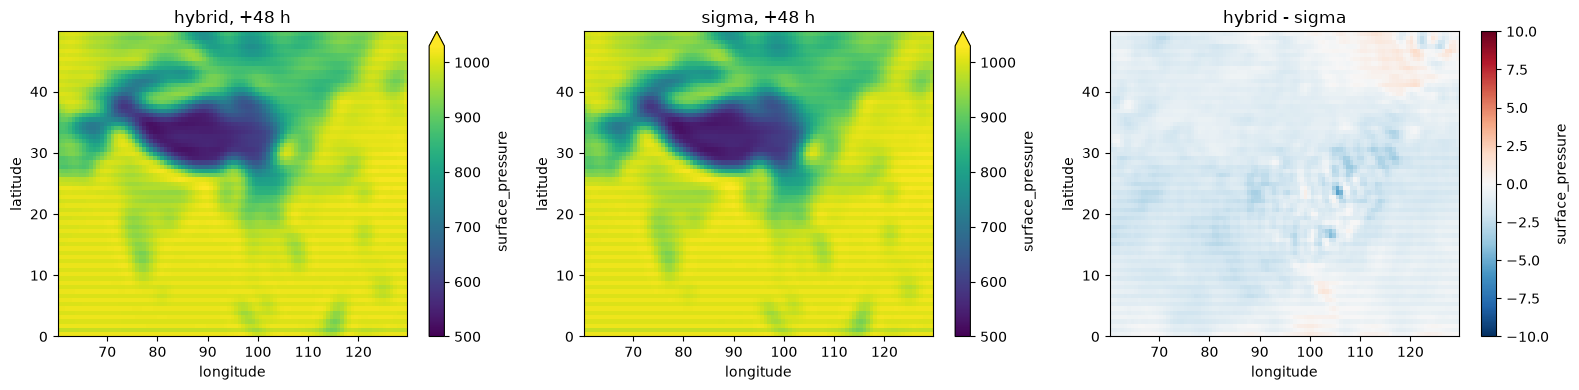

In [13]:
region = dict(longitude=slice(60, 130), latitude=slice(0, 50))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, field) in zip(axes, [
    ('hybrid, +48 h', ds_hybrid.surface_pressure.sel(time=48)),
    ('sigma, +48 h', ds_sigma.surface_pressure.sel(time=48)),
    ('hybrid - sigma', ds_hybrid.surface_pressure.sel(time=48) - ds_sigma.surface_pressure.sel(time=48)),
]):
  kwargs = dict(cmap='RdBu_r', vmin=-10, vmax=10) if 'hybrid - sigma' in title else dict(cmap='viridis', vmin=500, vmax=1030)
  field.sel(**region).plot.imshow(ax=ax, x='longitude', y='latitude', **kwargs)
  ax.set_title(title)
plt.tight_layout()

### Temperature on model levels

Temperature on the four output levels at +48 h. The `eta` coordinate is the
level's `A / 1013.25 hPa + B`, which coincides with sigma for a standard
surface pressure.

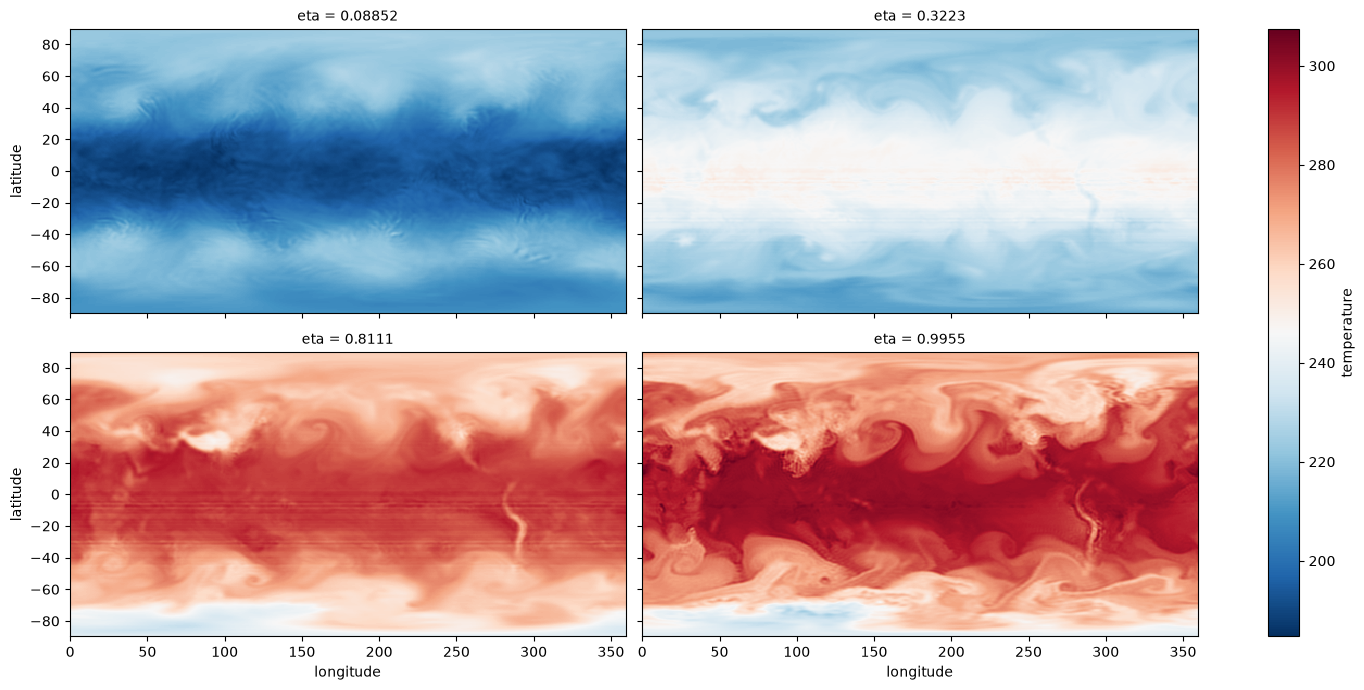

In [14]:
ds_hybrid.temperature.sel(time=48).plot.imshow(
    col='eta', x='longitude', y='latitude',
    col_wrap=2, aspect=2, size=3.5, cmap='RdBu_r',
)

### A cross-section through the level structure

Temperature along 30°N on the model levels as a function of pressure, with
the pressure of each output level drawn as a line: over the Tibetan plateau
(80-100°E) the lowest level follows the terrain while the upper levels stay
close to constant pressure.

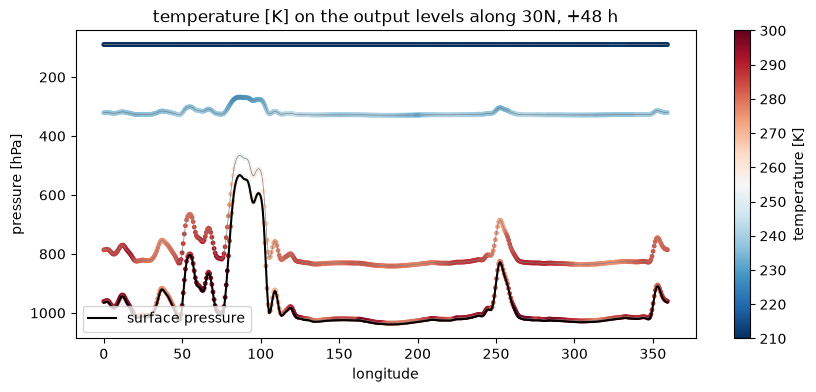

In [15]:
section = ds_hybrid.sel(time=48, latitude=30, method='nearest')
fig, ax = plt.subplots(figsize=(10, 4))
for eta in section.eta.values:
  level = section.sel(eta=eta)
  sc = ax.scatter(level.longitude, level.pressure, c=level.temperature, cmap='RdBu_r', vmin=210, vmax=300, s=6)
  ax.plot(level.longitude, level.pressure, color='gray', lw=0.5)
ax.plot(section.longitude, section.surface_pressure, color='k', lw=1.5, label='surface pressure')
ax.invert_yaxis()
ax.set(xlabel='longitude', ylabel='pressure [hPa]', title='temperature [K] on the output levels along 30N, +48 h')
ax.legend(loc='lower left')
plt.colorbar(sc, ax=ax, label='temperature [K]')